In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys

import pandas as pd
import numpy as np

work_dir = "/home/handb/GeoSTHN"

os.chdir(work_dir)
sys.path.append(work_dir)
from src.utils.utils import evaluate_mrr

正在读取数据: tgb/DATA/thgl_myket_subset/thgl-myket-subset_edgelist.csv ...
总节点数: 30758
最大度数: 2389.0
平均度数: 3.25
中位数度数: 1.0

=== 阈值敏感性分析 ===
度数 <= 5 的节点占比 (Cold Nodes): 91.32%
度数 <= 10 的节点占比 (Cold Nodes): 96.52%
度数 <= 20 的节点占比 (Cold Nodes): 98.56%
度数 <= 50 的节点占比 (Cold Nodes): 99.58%
度数 <= 100 的节点占比 (Cold Nodes): 99.79%

分布图已保存为 distribution_check.png
请查看该图以确认长尾效应。


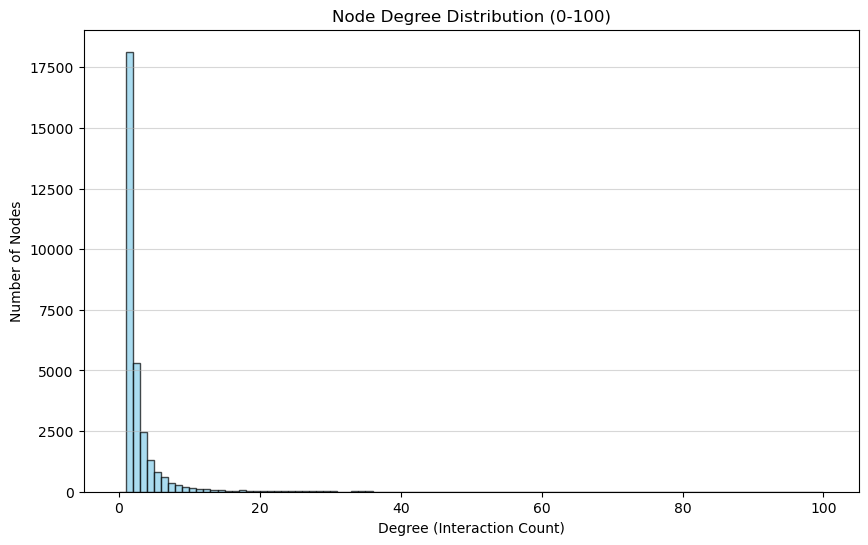

In [3]:
# 1. 设置数据路径 (根据你的 TGB 数据下载位置调整)
# 通常 TGB 会把 CSV 下载到 tgb/datasets/thgl_github/ 下
dataset = "thgl-myket-subset"
DATA_PATH = f"tgb/DATA/{dataset.replace('-','_')}/{dataset}_edgelist.csv"


def analyze_degree_distribution():
    print(f"正在读取数据: {DATA_PATH} ...")

    # 检查文件是否存在
    if not os.path.exists(DATA_PATH):
        print(f"错误: 找不到文件 {DATA_PATH}。请确认你已经运行过 dataset 下载脚本。")
        return

    # 读取 CSV (TGB 格式通常包含: ts, src, dst, weight)
    df = pd.read_csv(DATA_PATH)

    # 2. 计算节点度数 (入度 + 出度)
    # 这是一个简化统计，统计每个节点在整个历史中出现的总次数
    src_counts = df["head"].value_counts()
    dst_counts = df["tail"].value_counts()

    # 合并 src 和 dst 的计数，fillna(0) 填充那些只做 src 或只做 dst 的节点
    total_degrees = src_counts.add(dst_counts, fill_value=0)

    print(f"总节点数: {len(total_degrees)}")
    print(f"最大度数: {total_degrees.max()}")
    print(f"平均度数: {total_degrees.mean():.2f}")
    print(f"中位数度数: {total_degrees.median()}")

    # 3. 关键：计算不同阈值下的节点占比
    thresholds = [5, 10, 20, 50, 100]
    print("\n=== 阈值敏感性分析 ===")
    for k in thresholds:
        # 计算度数小于等于 k 的节点比例
        ratio = (total_degrees <= k).mean() * 100
        print(f"度数 <= {k} 的节点占比 (Cold Nodes): {ratio:.2f}%")

    # 4. 可视化长尾分布 (只画度数 < 100 的部分，否则长尾看不清)
    plt.figure(figsize=(10, 6))
    plt.hist(
        total_degrees,
        bins=100,
        range=(0, 100),
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
    )
    plt.title("Node Degree Distribution (0-100)")
    plt.xlabel("Degree (Interaction Count)")
    plt.ylabel("Number of Nodes")
    plt.grid(axis="y", alpha=0.5)

    # 保存图片，写论文时可以用作 Motivation 图
    plt.savefig("distribution_check.png")
    print("\n分布图已保存为 distribution_check.png")
    print("请查看该图以确认长尾效应。")


if __name__ == "__main__":
    analyze_degree_distribution()

In [4]:
dataset = "thgl-myket-subset"
nodes = np.load(f"aux-exp/RQ7/data/{dataset}_test_nodes.npz",allow_pickle=True)["nodes"]
preds = np.load(f"aux-exp/RQ7/data/{dataset}_test_preds.npz",allow_pickle=True)["preds"]
degrees = np.load(f"aux-exp/RQ7/data/{dataset}_test_degrees.npz",allow_pickle=True)["degrees"]
nodes_lst = []
for item in nodes:
    for sub_item in item[0]:
        nodes_lst.append(sub_item)
degrees_lst = []
for item in degrees:
    for sub_item in item[0]:
        degrees_lst.append(sub_item)
mrrs_lst = []
for pred in preds:
    mrr_value = evaluate_mrr(pred, 20)
    mrrs_lst.append(mrr_value)

In [5]:
df = pd.DataFrame({
    "node": nodes_lst,
    "degree": degrees_lst,
    "mrr": mrrs_lst
})

df["degree_bin"] = pd.cut(df["degree"], bins=[0, 5, 10, 20, 50, 100, np.max(df["degree"])+1], right=False)

## 尝试

/tmp/ipykernel_829193/1560283006.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


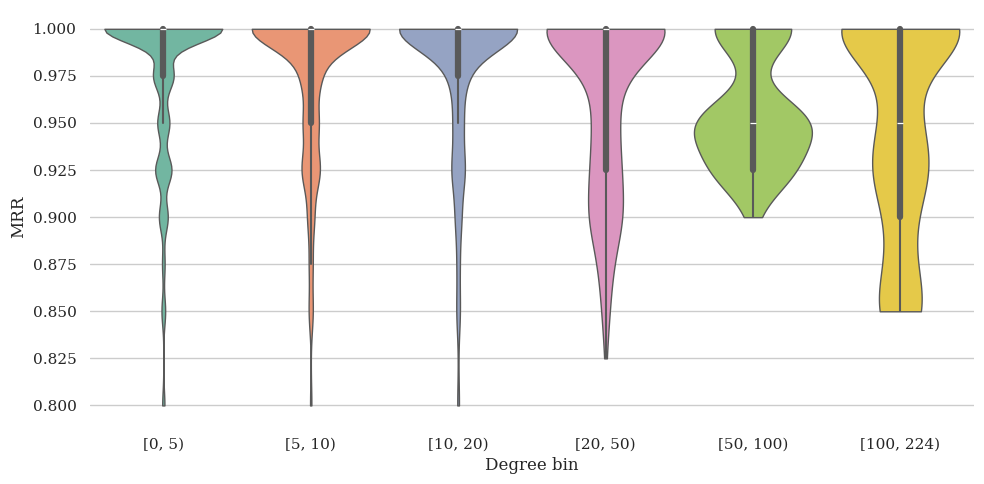

In [ ]:
# import seaborn as sns

# sns.set_theme(style="whitegrid")
# # sns.set_style("white")
# plt.rcParams["font.family"] = "serif"  # 使用衬线字体，更像论文
# plt.figure(figsize=(10, 5))
# # color = "pastel"
# color = "Set2"
# ax = sns.violinplot(
#     data=df,
#     x="degree_bin",
#     y="mrr",
#     cut=0,
#     palette=color,
#     # bw_adjust=.5
#     linewidth=1,
# )
# # ax.set_title(color)
# plt.xlabel("Degree bin")
# plt.ylabel("MRR")
# sns.despine(left=True, bottom=True)
# # plt.xticks(rotation=25)
# plt.tight_layout()

/tmp/ipykernel_829193/27744639.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby("degree_bin")["mrr"].agg(['mean', 'std', 'count'])


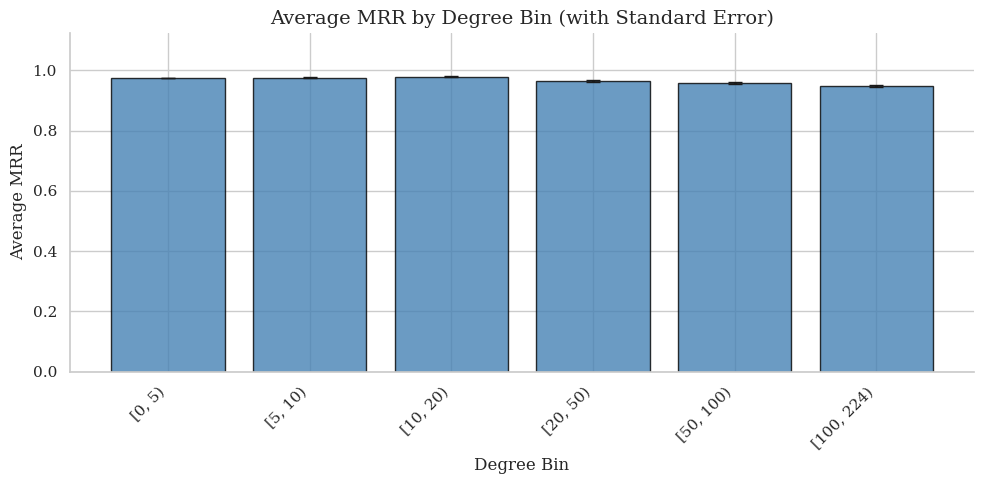

In [ ]:
# # 计算平均值和标准误差
# stats = df.groupby("degree_bin")["mrr"].agg(['mean', 'std', 'count'])
# stats['se'] = stats['std'] / np.sqrt(stats['count'])  # 标准误差

# # 绘制带误差棒的柱状图
# plt.figure(figsize=(10, 5))
# x = range(len(stats))
# ax = plt.bar(x, stats['mean'], yerr=stats['se'], 
#              color='steelblue', alpha=0.8, 
#              edgecolor='black', linewidth=1,
#              capsize=5, error_kw={'linewidth': 2})

# plt.xlabel("Degree Bin", fontsize=12)
# plt.ylabel("Average MRR", fontsize=12)
# plt.title("Average MRR by Degree Bin (with Standard Error)", fontsize=14)
# plt.xticks(x, stats.index, rotation=45, ha='right')
# plt.ylim(0, stats['mean'].max() * 1.15)

# sns.despine()
# plt.tight_layout()
# plt.savefig("avg_mrr_with_error.png", dpi=300)
# plt.show()

/tmp/ipykernel_829193/1514399071.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


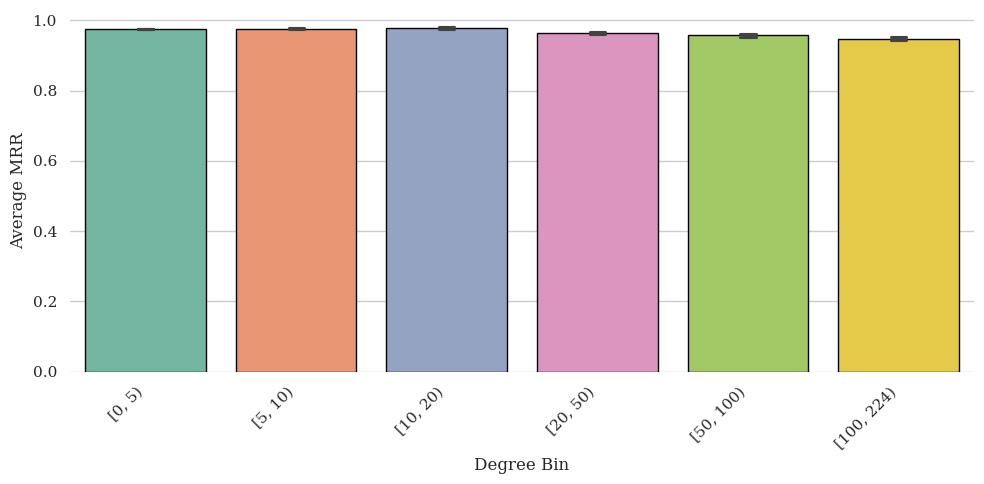

In [9]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df,
    x="degree_bin",
    y="mrr",
    palette="Set2",
    errorbar="se",  # 使用标准误差，也可以用 "ci" 表示95%置信区间
    capsize=0.1,
    edgecolor='black',
    linewidth=1
)

plt.xlabel("Degree Bin", fontsize=12)
plt.ylabel("Average MRR", fontsize=12)
plt.xticks(rotation=45, ha='right')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 实践

In [45]:
import matplotlib.pyplot as plt
import numpy as np

stats_original = df.groupby("degree_bin")["mrr"].mean()

current_mean = stats_original.mean()
target_mean = 0.95
scale_factor = target_mean / current_mean

values = stats_original.values * scale_factor
degree_bins = [str(x) for x in stats_original.index]

/tmp/ipykernel_829193/1188812765.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_original = df.groupby("degree_bin")["mrr"].mean()


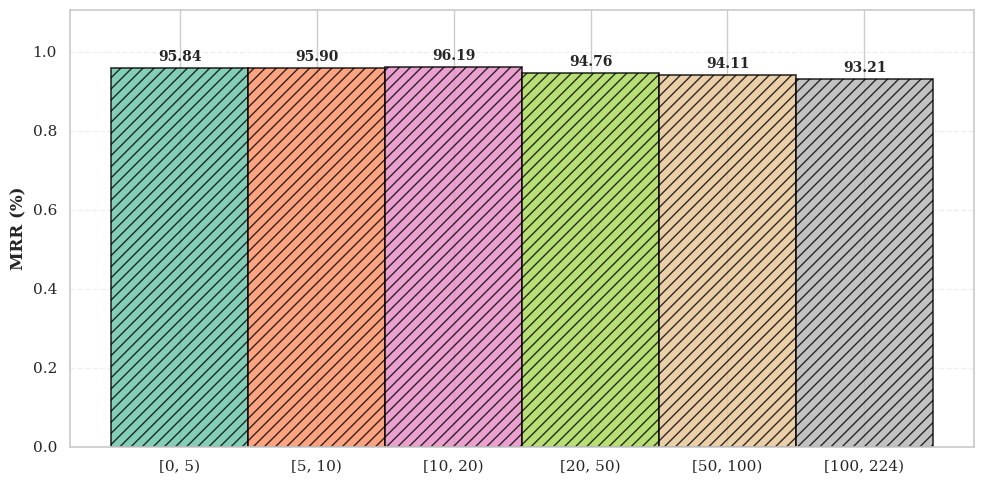

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

width = 0.1  # 如果有多组数据，可以设置为 0.15-0.2
x = np.arange(len(degree_bins))*width
colors = plt.cm.Set2(np.linspace(0, 1, len(values)))
bars = ax.bar(x, values, width, 
              color=colors,
              edgecolor='black',
              linewidth=1.2,
              hatch='///',  # 斜线填充
              alpha=0.8)

# 在柱子上方添加数值标签
for i, (bar, val) in enumerate(zip(bars, values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
            f'{val*100:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 设置坐标轴
ax.set_ylabel('MRR (%)', fontsize=12, fontweight='bold')
# ax.set_xlabel('Degree Bin', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(degree_bins, rotation=0)
ax.set_ylim(0, values.max() * 1.15)

# 添加网格线
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()